# Download Full RVL-CDIP Dataset

Downloads the full RVL-CDIP dataset (400k images, 16 classes) from HuggingFace to an external drive.
The dataset is stored as Parquet files on HuggingFace — `load_dataset` downloads and converts to Arrow cache automatically.
After this notebook completes, the dataset is ready for use by other notebooks.

**Storage**: `/Volumes/sp-ext/rvl-cdip/`

**Dataset**: `chainyo/rvl-cdip` (Parquet) — 320k train / 40k val / 40k test

**Why not `aharley/rvl_cdip`?** That repo uses a custom loading script (`rvl_cdip.py`) which is
[no longer supported](https://discuss.huggingface.co/t/dataset-scripts-are-no-longer-supported/163891)
by the `datasets` library. `chainyo/rvl-cdip` is the same data pre-converted to Parquet format.

---

## Switching existing notebooks to the full dataset

Add these lines to the first code cell of any notebook, **before** `Config()` is called:

```python
os.environ["DATA_MODE"] = "full"
os.environ["HF_CACHE_DIR"] = "/Volumes/sp-ext/rvl-cdip/hf_cache"
os.environ["CACHE_DIR"] = "/Volumes/sp-ext/rvl-cdip/cached_features"
```

---

## 1. Setup

In [1]:
import os

import httpx
from huggingface_hub.utils._http import (
    hf_request_event_hook,
    set_client_factory,
)

# Work around macOS Python SSL cert verification failure.
# huggingface_hub uses httpx internally — override its client factory
# to skip SSL verification for this dataset download session.
set_client_factory(lambda: httpx.Client(
    verify=False,
    event_hooks={"request": [hf_request_event_hook]},
    follow_redirects=True,
    timeout=None,
))

DATA_ROOT = "/Volumes/sp-ext/rvl-cdip"

os.environ["DATA_MODE"] = "full"
os.environ["HF_CACHE_DIR"] = f"{DATA_ROOT}/hf_cache"
os.environ["CACHE_DIR"] = f"{DATA_ROOT}/cached_features"

import sys
sys.path.insert(0, "..")

from pathlib import Path

from src.config import Config
from src.data import load_rvl_cdip, RVL_CDIP_LABELS

# Verify external drive is mounted
assert Path(DATA_ROOT).parent.exists(), f"Drive not mounted: {Path(DATA_ROOT).parent}"
print(f"External drive OK: {Path(DATA_ROOT).parent}")

/Users/sagarpratapsingh/dev/sagerstack/deep-learning-doc-classification/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


External drive OK: /Volumes/sp-ext


In [2]:
config = Config()

print(f"\nConfiguration:")
print(f"  Mode: {config.mode}")
print(f"  Dataset: {config.dataset_name}")
print(f"  HF cache: {config.hf_cache_dir}")
print(f"  Features cache: {config.cache_dir}")

Device: mps
Mode: full
Sample size: 100

Configuration:
  Mode: full
  Dataset: chainyo/rvl-cdip
  HF cache: /Volumes/sp-ext/rvl-cdip/hf_cache
  Features cache: /Volumes/sp-ext/rvl-cdip/cached_features


## 2. Download Dataset

Downloads 149 Parquet files (~46 GB) from HuggingFace, then converts to Arrow cache.
Total disk usage: ~80-100 GB (Parquet download + Arrow cache). Ensure the external drive has sufficient space.

In [3]:
import shutil

total, used, free = shutil.disk_usage(DATA_ROOT)
free_gb = free / (1024 ** 3)
print(f"Free space on drive: {free_gb:.1f} GB")
assert free_gb > 100, f"Need at least 100GB free, only {free_gb:.1f}GB available"

Free space on drive: 238.4 GB


In [4]:
data = load_rvl_cdip(config)

print(f"\nDataset splits:")
for split_name, split_data in data.items():
    print(f"  {split_name}: {len(split_data):,} samples")

print(f"\nClass labels ({len(RVL_CDIP_LABELS)} classes):")
for i, label in enumerate(RVL_CDIP_LABELS):
    print(f"  {i}: {label}")

Loading full dataset to cache: /Volumes/sp-ext/rvl-cdip/hf_cache...


Generating val split: 100%|██████████| 40000/40000 [01:51<00:00, 357.59 examples/s] 


Loaded train: 319999 samples
Loaded test: 40000 samples
Loaded validation: 40000 samples

Dataset splits:
  train: 319,999 samples
  test: 40,000 samples
  validation: 40,000 samples

Class labels (16 classes):
  0: advertisement
  1: budget
  2: email
  3: file folder
  4: form
  5: handwritten
  6: invoice
  7: letter
  8: memo
  9: news article
  10: presentation
  11: questionnaire
  12: resume
  13: scientific publication
  14: scientific report
  15: specification


## 3. Verify Download

In [5]:
# Verify expected split sizes
expected = {"train": 320_000, "validation": 40_000, "test": 40_000}

for split_name, expected_size in expected.items():
    actual = len(data[split_name])
    status = "OK" if actual == expected_size else "MISMATCH"
    print(f"  {split_name}: {actual:>7,} (expected {expected_size:,}) [{status}]")

# Verify cache directory on disk
hf_cache = Path(config.hf_cache_dir)
cache_files = list(hf_cache.rglob("*.arrow"))
cache_size_gb = sum(f.stat().st_size for f in hf_cache.rglob("*") if f.is_file()) / (1024 ** 3)
print(f"\nHF cache: {len(cache_files)} arrow files, {cache_size_gb:.1f} GB on disk")
print(f"Location: {hf_cache.resolve()}")

  train: 319,999 (expected 320,000) [MISMATCH]
  validation:  40,000 (expected 40,000) [OK]
  test:  40,000 (expected 40,000) [OK]

HF cache: 156 arrow files, 45.2 GB on disk
Location: /Volumes/sp-ext/rvl-cdip/hf_cache


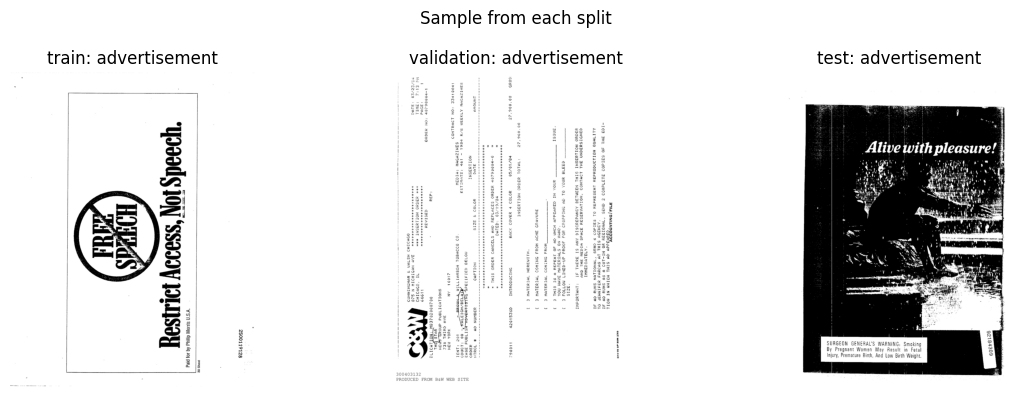

In [6]:
# Spot-check: display one sample from each split
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, split_name in zip(axes, ["train", "validation", "test"]):
    sample = data[split_name][0]
    ax.imshow(sample["image"], cmap="gray")
    label_name = RVL_CDIP_LABELS[sample["label"]]
    ax.set_title(f"{split_name}: {label_name}")
    ax.axis("off")

plt.suptitle("Sample from each split")
plt.tight_layout()
plt.show()

## 4. Label Distribution

/Users/sagarpratapsingh/dev/sagerstack/deep-learning-doc-classification/.venv/lib/python3.13/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Corrupt EXIF data.  Expecting to read 2 bytes but only got 0. 
  warnings.warn(str(msg))


UnidentifiedImageError: cannot identify image file <_io.BytesIO object at 0x132721df0>

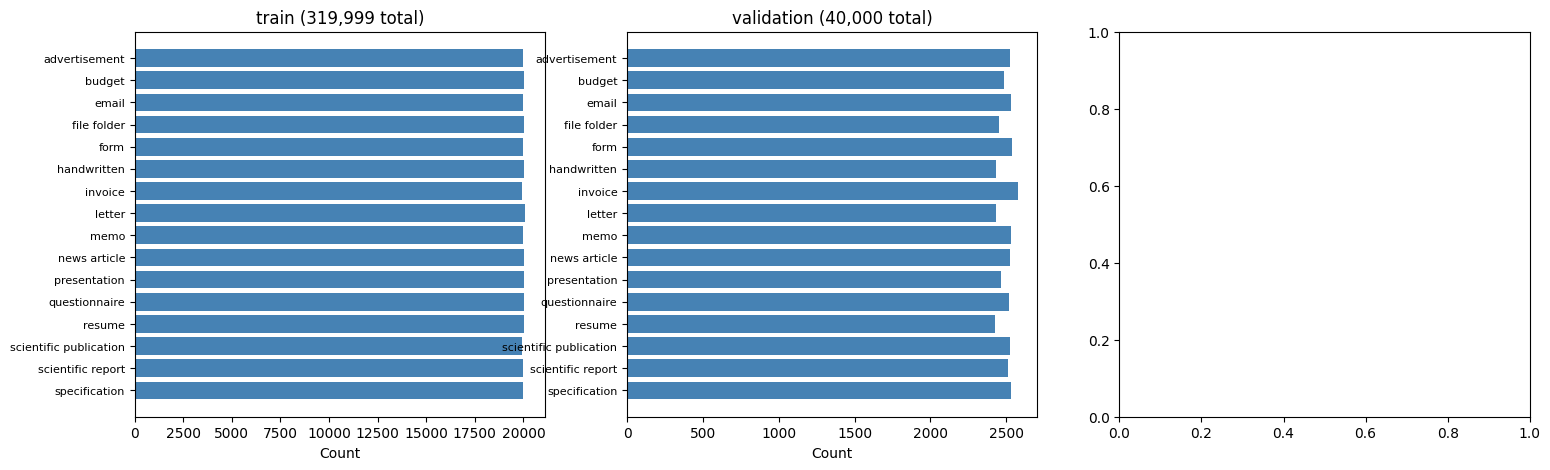

In [7]:
from collections import Counter

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, split_name in zip(axes, ["train", "validation", "test"]):
    labels = [s["label"] for s in data[split_name]]
    counts = Counter(labels)
    sorted_counts = [counts[i] for i in range(len(RVL_CDIP_LABELS))]

    ax.barh(range(len(RVL_CDIP_LABELS)), sorted_counts, color="steelblue")
    ax.set_yticks(range(len(RVL_CDIP_LABELS)))
    ax.set_yticklabels(RVL_CDIP_LABELS, fontsize=8)
    ax.set_title(f"{split_name} ({len(labels):,} total)")
    ax.set_xlabel("Count")
    ax.invert_yaxis()

plt.suptitle("Label Distribution per Split")
plt.tight_layout()
plt.show()